# Experiments: Activation Functions & Regularization (Anggota B)

Notebook ini untuk Day 4 bagian Anggota B:
- Eksperimen aktivasi: `linear`, `relu`, `sigmoid`, `tanh`
- Eksperimen regularisasi: `none`, `l1`, `l2`
- Plot loss curve + distribusi bobot dan gradien


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from ffnn import FFNN


## 1) Dataset

Kalau dataset project belum siap dibaca dari file, notebook ini pakai synthetic dataset supaya eksperimen tetap bisa jalan end-to-end.


In [2]:
SEED = 42
np.random.seed(SEED)

X, y = make_classification(
    n_samples=1500,
    n_features=16,
    n_informative=10,
    n_redundant=2,
    n_classes=3,
    random_state=SEED
)

scaler = StandardScaler()
X = scaler.fit_transform(X)

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

X_train, X_val, y_train, y_val = train_test_split(
    X, y_onehot, test_size=0.2, random_state=SEED, stratify=y
)

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)


Train: (1200, 16) (1200, 3)
Val  : (300, 16) (300, 3)


## 2) Helper: training loop sederhana

Karena `fit()` belum tentu sudah final dari anggota lain, kita pakai mini loop di notebook supaya eksperimen bisa langsung dijalankan.


In [3]:
def argmax_accuracy(y_true_onehot, y_pred_prob):
    y_true_idx = np.argmax(y_true_onehot, axis=1)
    y_pred_idx = np.argmax(y_pred_prob, axis=1)
    return np.mean(y_true_idx == y_pred_idx)


def mini_batch_iter(X, y, batch_size=32, shuffle=True, seed=42):
    n = X.shape[0]
    idx = np.arange(n)
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)

    for i in range(0, n, batch_size):
        batch_idx = idx[i:i+batch_size]
        yield X[batch_idx], y[batch_idx]


def train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=60,
    lr=0.01,
    batch_size=64,
    loss_type='categorical_crossentropy',
    reg_type=None,
    lambda_=0.0,
    seed=42,
):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
    }

    for epoch in range(epochs):
        for xb, yb in mini_batch_iter(X_train, y_train, batch_size=batch_size, shuffle=True, seed=seed+epoch):
            model.forward(xb)
            model.backward(yb, loss_type=loss_type, reg_type=reg_type, lambda_=lambda_)

            for i in range(len(model.weights)):
                model.weights[i] -= lr * model.grad_weights[i]
                model.biases[i] -= lr * model.grad_biases[i]

        y_train_pred = model.forward(X_train)
        y_val_pred = model.forward(X_val)

        train_loss = model.compute_loss(y_train, y_train_pred, loss_type=loss_type, reg_type=reg_type, lambda_=lambda_)
        val_loss = model.compute_loss(y_val, y_val_pred, loss_type=loss_type, reg_type=reg_type, lambda_=lambda_)

        train_acc = argmax_accuracy(y_train, y_train_pred)
        val_acc = argmax_accuracy(y_val, y_val_pred)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    return history


## 3) Arsitektur base


In [4]:
input_dim = X_train.shape[1]
num_classes = y_train.shape[1]

base_layers = [input_dim, 32, 16, num_classes]  # minimal 3 layer network
test_layer_idx = 0  # layer hidden pertama dijadikan layer pengetesan aktivasi
epochs = 60
lr = 0.01
batch_size = 64
loss_type = 'categorical_crossentropy'

print('Base layers:', base_layers)
print('Layer pengetesan aktivasi: hidden layer ke-1 (index 0)')


Base layers: [16, 32, 16, 3]
Layer pengetesan aktivasi: hidden layer ke-1 (index 0)


## 4) Eksperimen Aktivasi

Kita ubah aktivasi di hidden layer pertama: `linear`, `relu`, `sigmoid`, `tanh`.
Layer hidden kedua tetap `relu`, output `softmax`.


In [5]:
activation_variants = ['linear', 'relu', 'sigmoid', 'tanh']
activation_results = {}
activation_models = {}

for act in activation_variants:
    print(f'Training activation={act} ...')

    acts = ['relu', 'relu', 'softmax']
    acts[test_layer_idx] = act
    model = FFNN(base_layers, acts, weight_initial='normal')

    hist = train_model(
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=epochs,
        lr=lr,
        batch_size=batch_size,
        loss_type=loss_type,
        reg_type=None,
        lambda_=0.0,
        seed=SEED,
    )

    activation_results[act] = hist
    activation_models[act] = model

print('Done.')


Training activation=linear ...
Training activation=relu ...
Training activation=sigmoid ...
Training activation=tanh ...
Done.


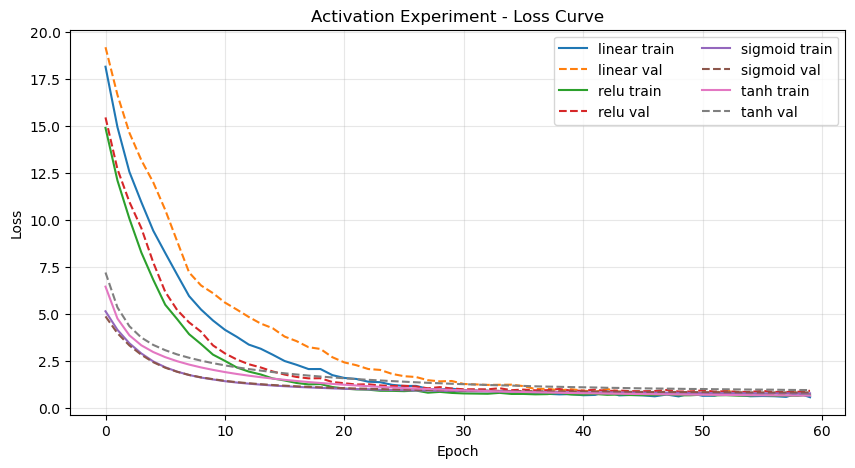

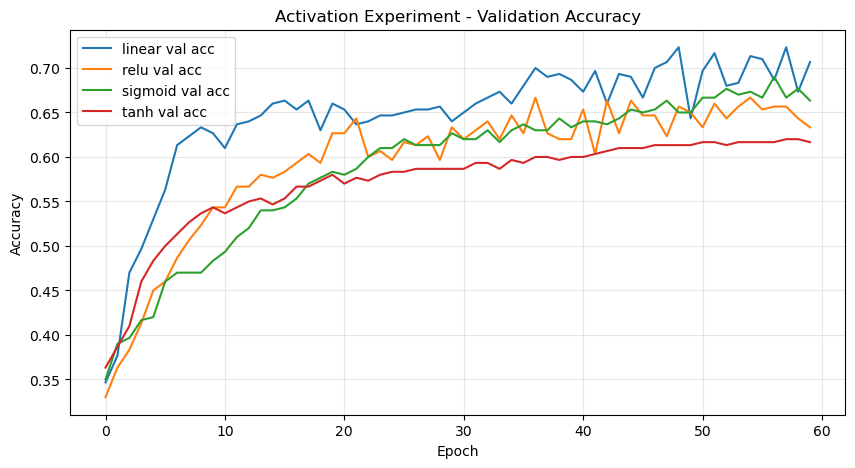

In [6]:
plt.figure(figsize=(10, 5))
for act, hist in activation_results.items():
    plt.plot(hist['train_loss'], label=f'{act} train')
    plt.plot(hist['val_loss'], linestyle='--', label=f'{act} val')
plt.title('Activation Experiment - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
for act, hist in activation_results.items():
    plt.plot(hist['val_acc'], label=f'{act} val acc')
plt.title('Activation Experiment - Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Perbandingan hasil akhir prediksi (aktivasi)

Menampilkan:
- akurasi akhir di validation set
- distribusi label prediksi akhir
- contoh prediksi untuk sampel yang sama

In [ ]:
y_val_true_idx = np.argmax(y_val, axis=1)
sample_n = 15
sample_idx = np.arange(sample_n)

print('=== Activation: Prediksi Final ===')
print('True labels :', y_val_true_idx[sample_idx])

for act in activation_variants:
    model = activation_models[act]
    y_val_prob = model.forward(X_val)
    y_val_pred_idx = np.argmax(y_val_prob, axis=1)

    final_acc = np.mean(y_val_pred_idx == y_val_true_idx)
    pred_counts = np.bincount(y_val_pred_idx, minlength=num_classes)

    print(f'\n[{act}] final val acc = {final_acc:.4f}')
    print('pred class distribution:', pred_counts)
    print('pred labels :', y_val_pred_idx[sample_idx])


=== Activation: Final Prediction Comparison ===
True labels (first 15): [1 0 0 1 2 1 2 2 1 2 0 2 0 0 1]

[linear] final val acc = 0.7067
pred class distribution: [104  97  99]
pred labels (first 15): [2 2 1 1 2 1 2 2 1 2 0 1 1 0 1]

[relu] final val acc = 0.6333
pred class distribution: [ 44 128 128]
pred labels (first 15): [2 1 1 0 2 1 2 2 1 2 2 2 1 1 0]

[sigmoid] final val acc = 0.6633
pred class distribution: [ 71 123 106]
pred labels (first 15): [2 0 0 1 2 1 2 2 1 0 2 2 1 1 2]

[tanh] final val acc = 0.6167
pred class distribution: [ 92 114  94]
pred labels (first 15): [2 1 0 1 2 0 2 1 1 0 2 0 0 1 1]


### Distribusi bobot & gradien (aktivasi)

Contoh visualisasi untuk tiap model hasil aktivasi.


== Activation: linear ==


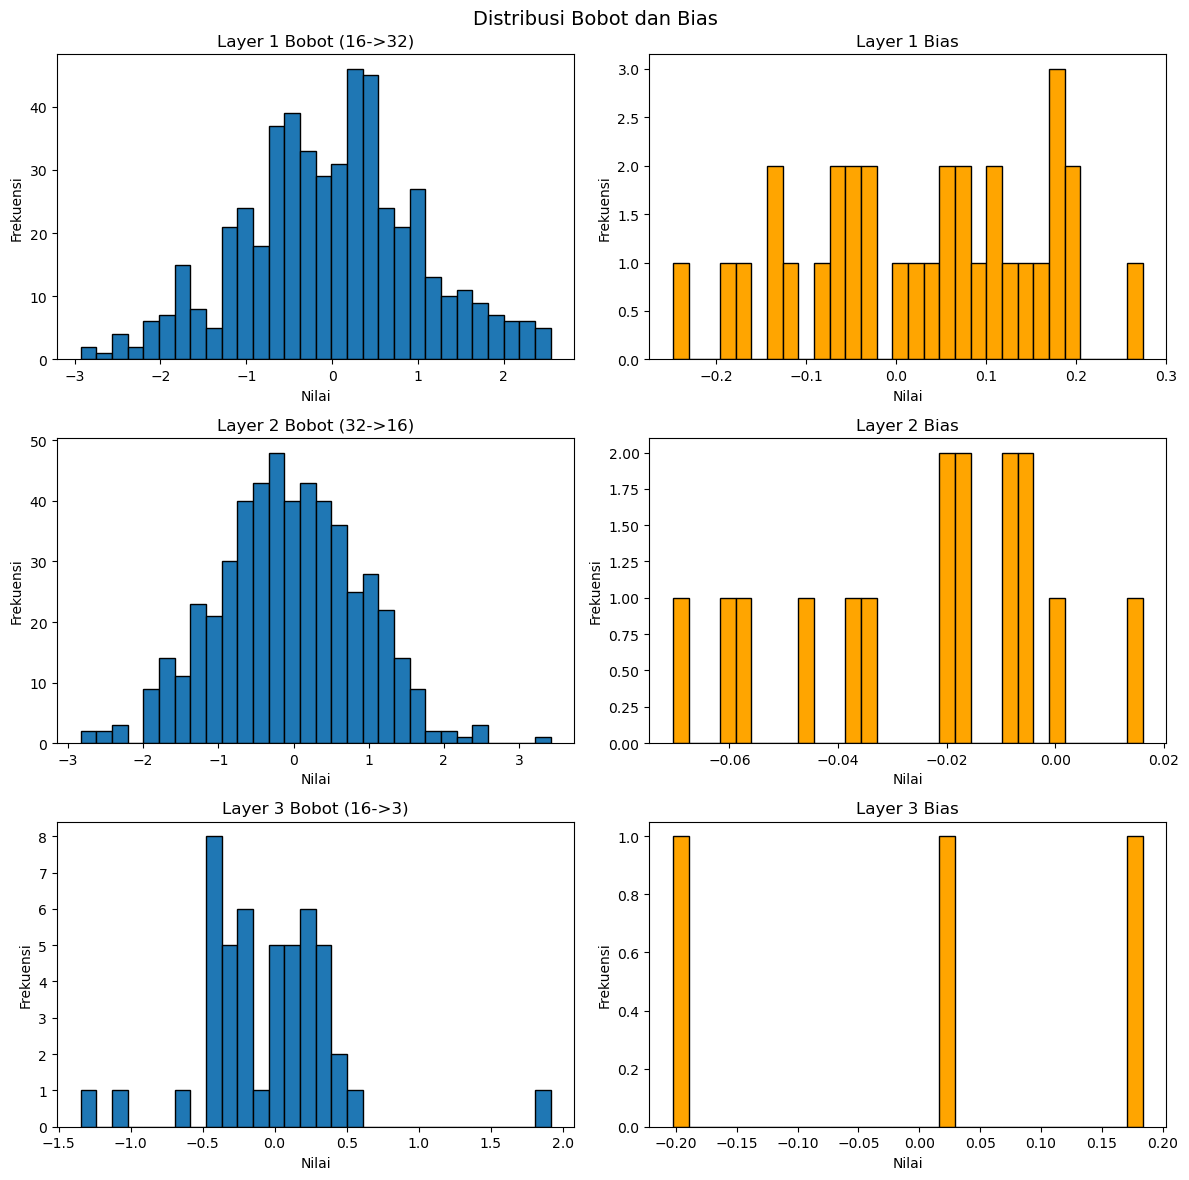

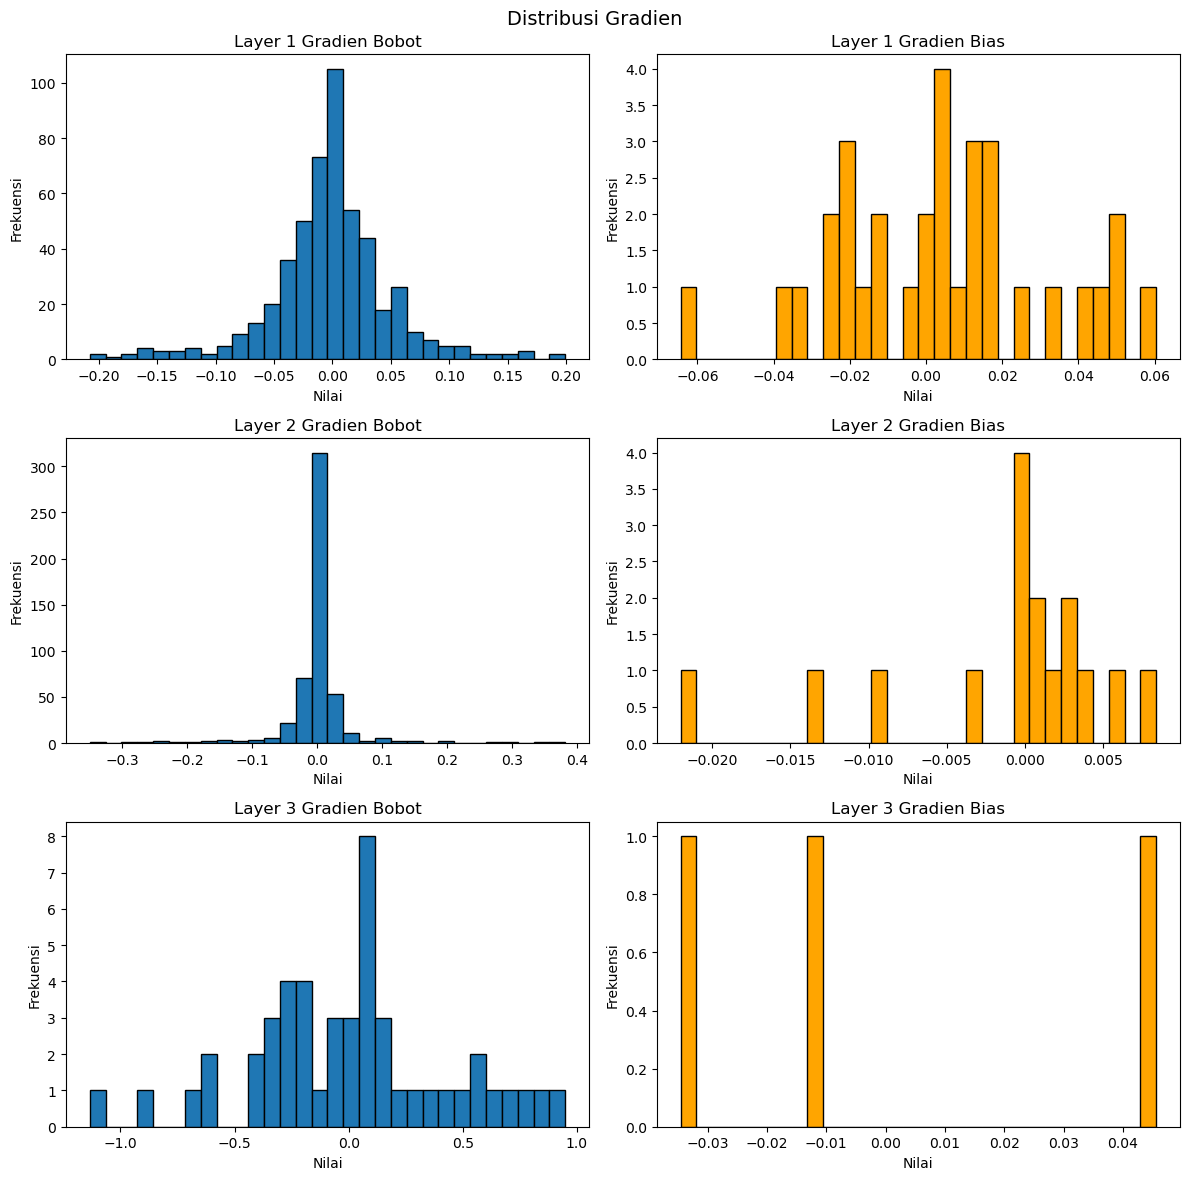

== Activation: relu ==


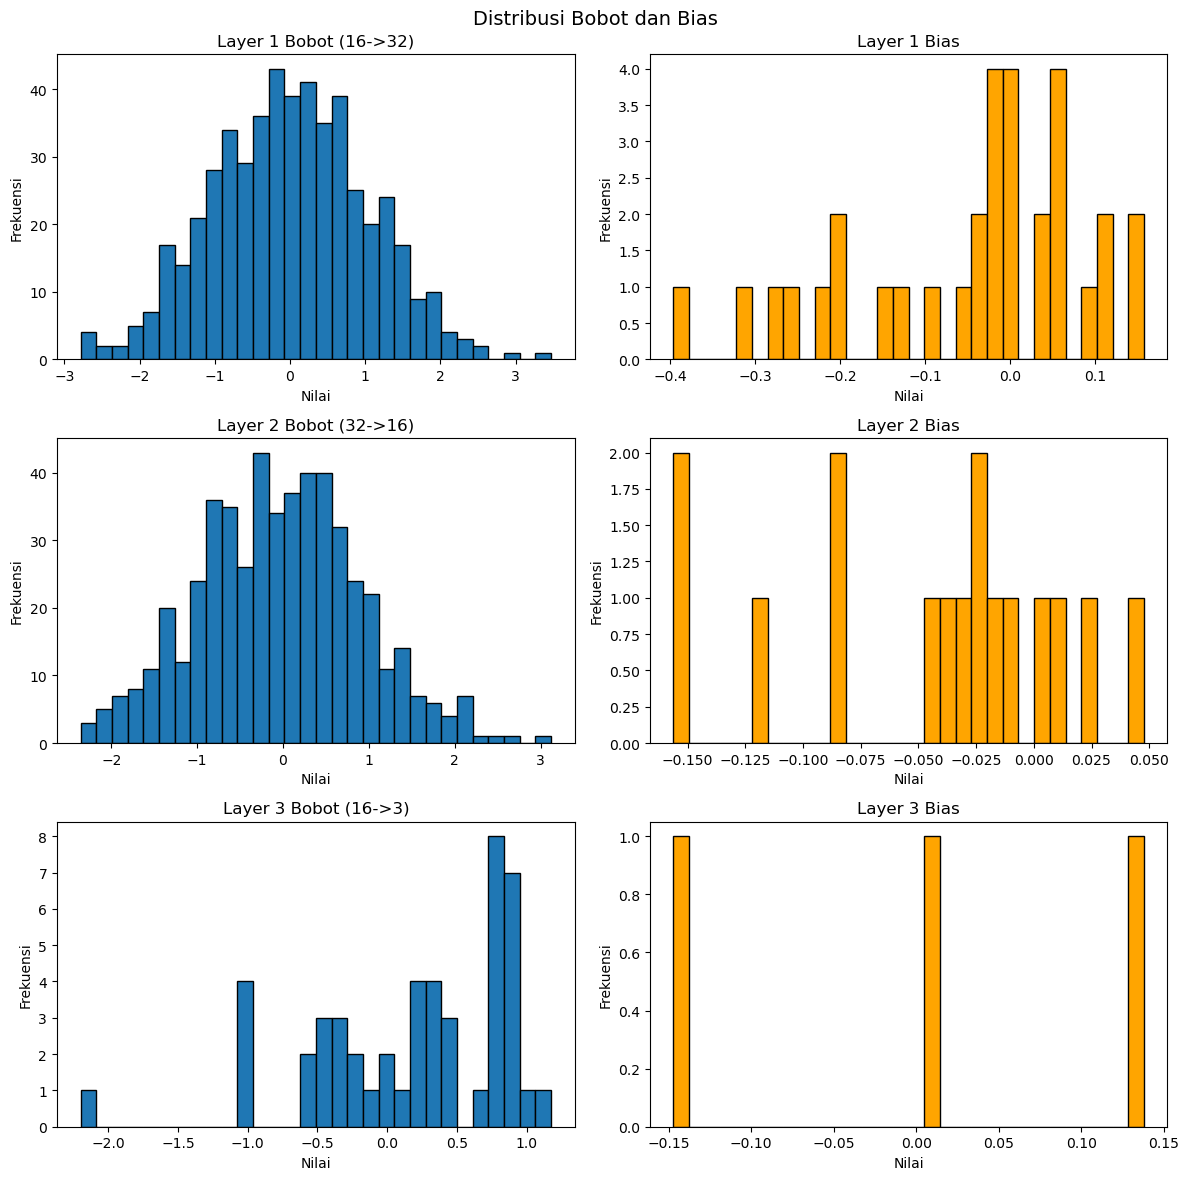

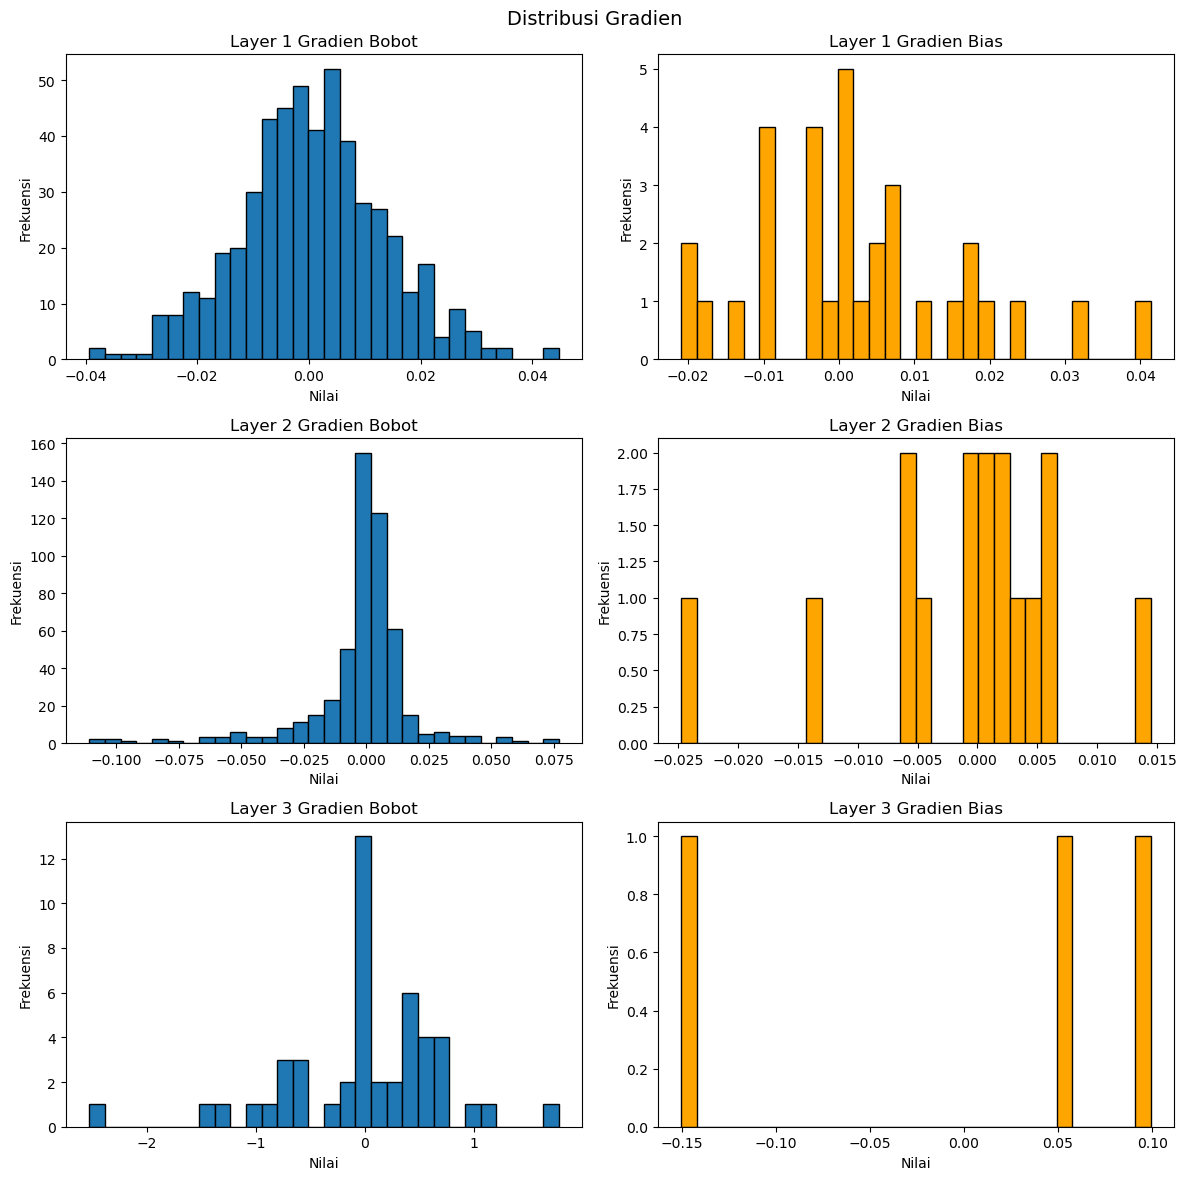

== Activation: sigmoid ==


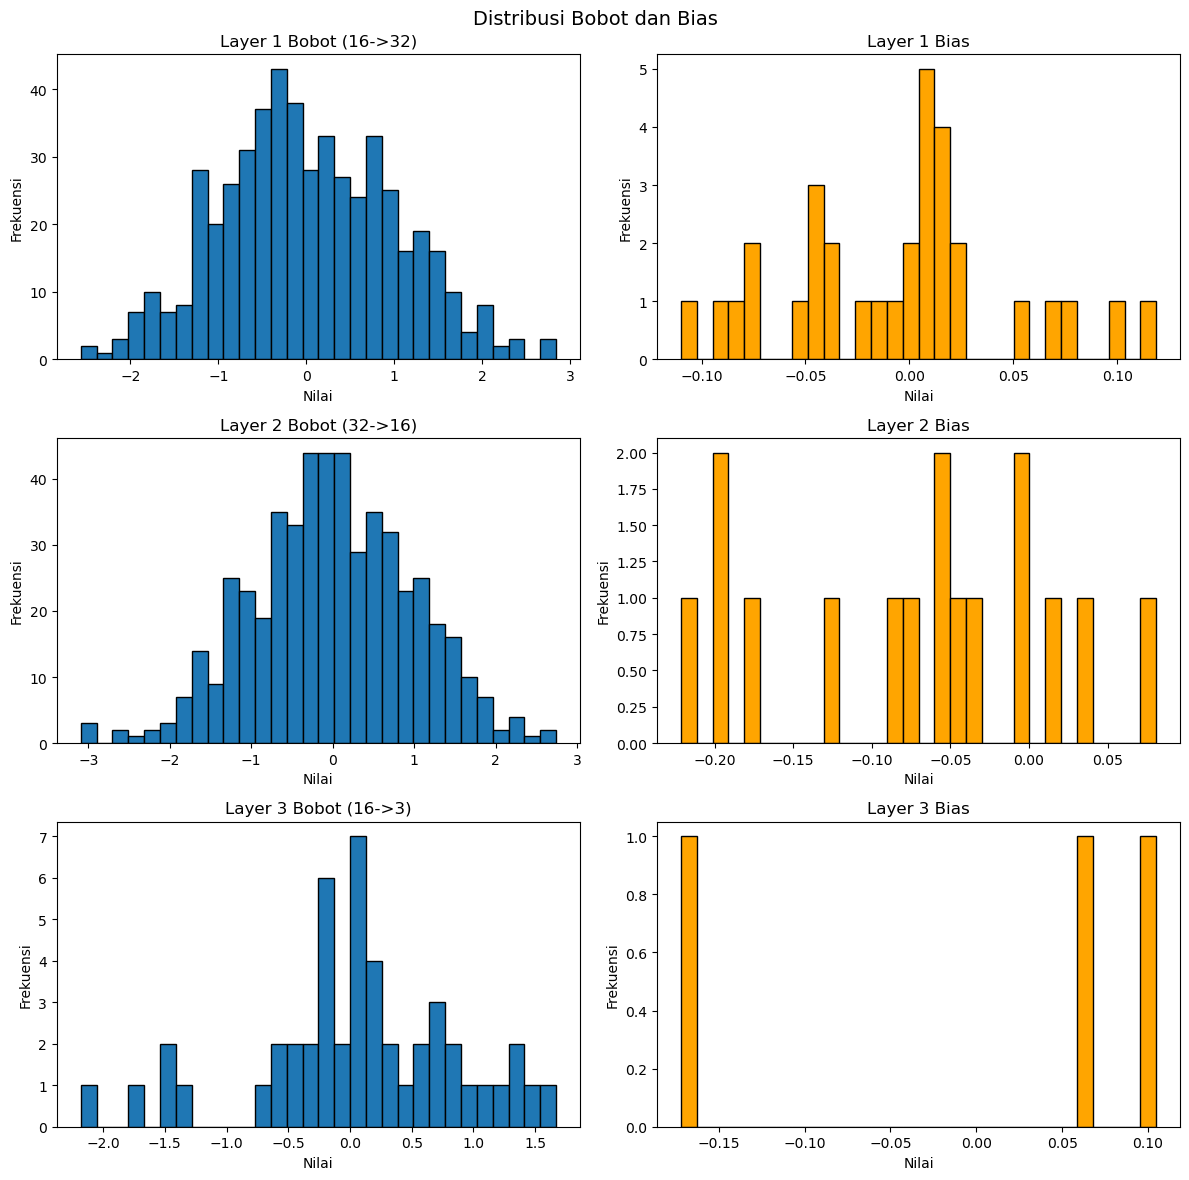

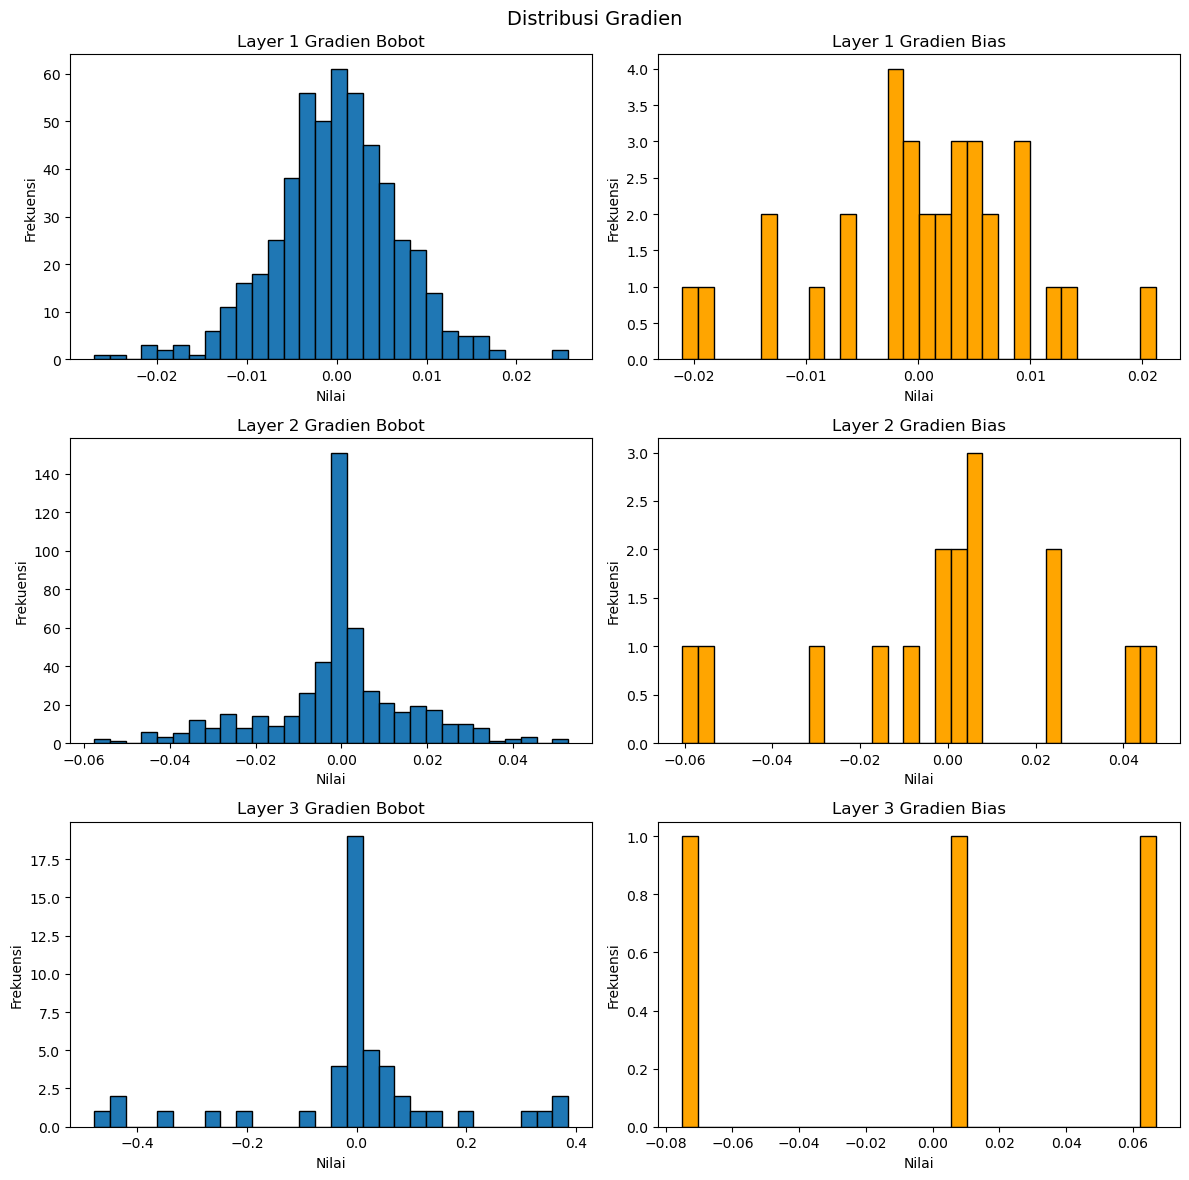

== Activation: tanh ==


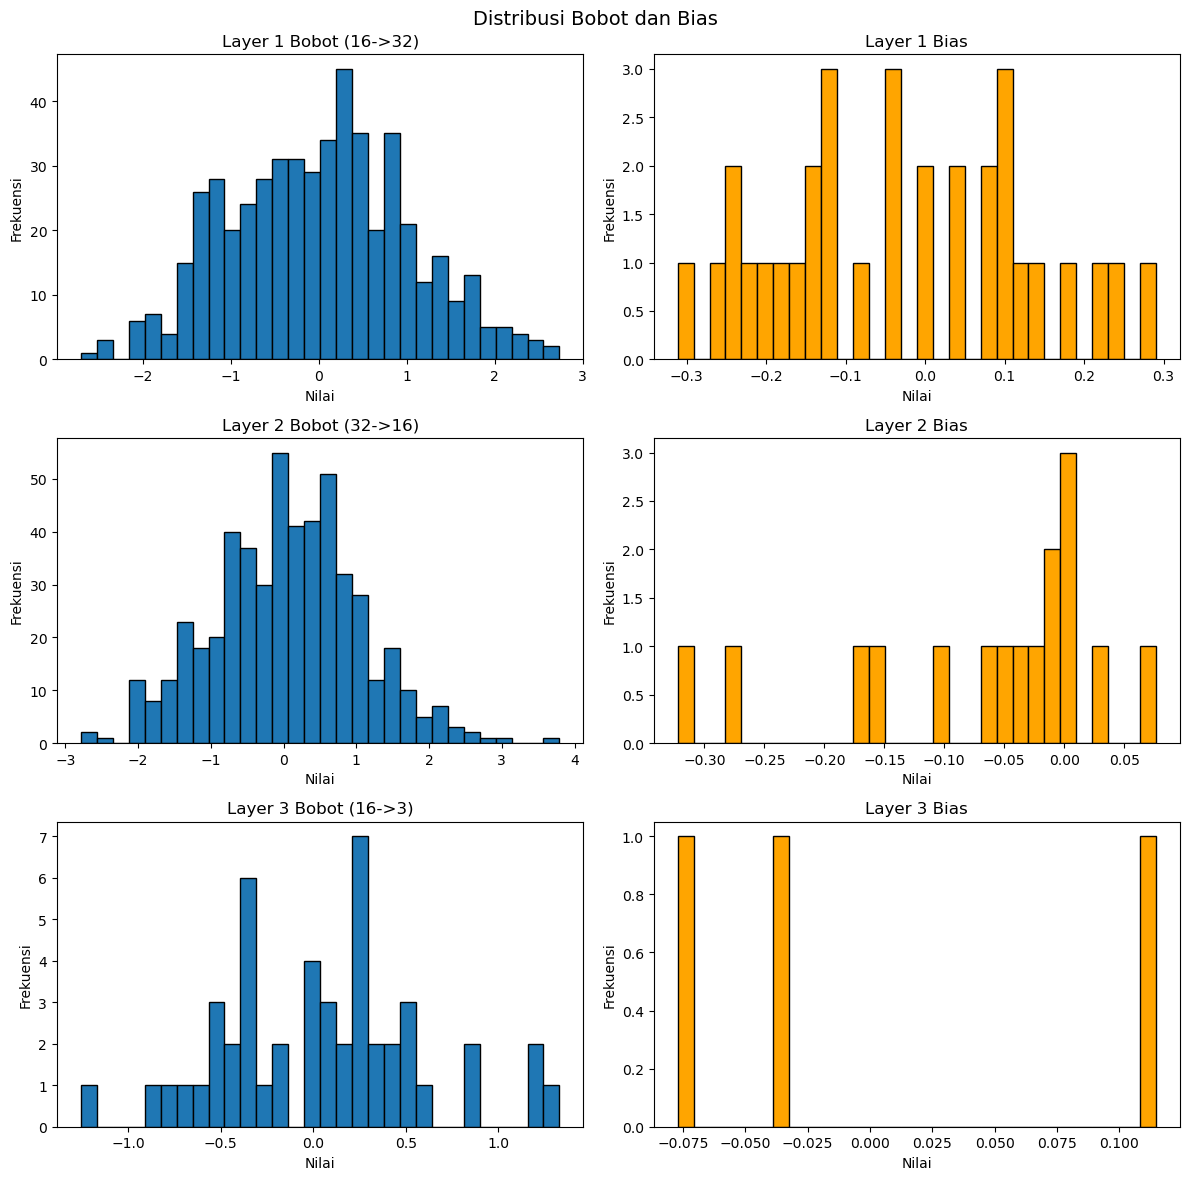

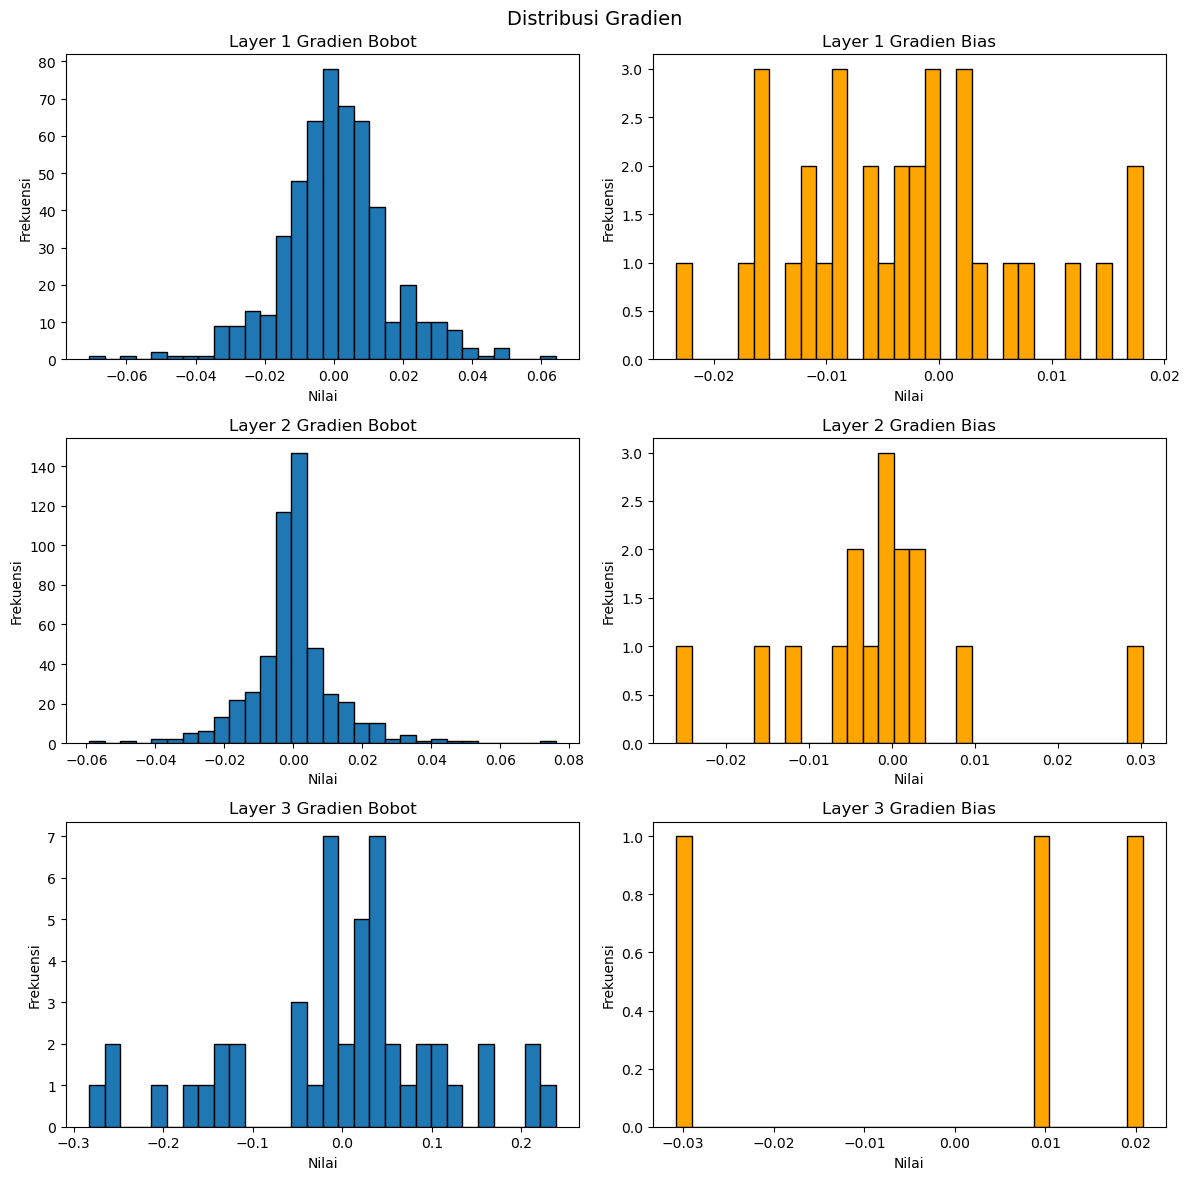

In [8]:
for act in activation_variants:
    model = activation_models[act]
    _ = model.forward(X_train[:128])
    _ = model.backward(y_train[:128], loss_type=loss_type)

    print(f'== Activation: {act} ==')
    model.plot_weight_distribution()
    model.plot_gradient_distribution()


## 5) Eksperimen Regularisasi

Tiga kondisi:
- tanpa regularisasi
- L1
- L2


In [9]:
regularization_variants = [
    ('none', None, 0.0),
    ('l1', 'l1', 1e-4),
    ('l2', 'l2', 1e-4),
]

regularization_results = {}
regularization_models = {}

for name, reg_type, lam in regularization_variants:
    print(f'Training regularization={name} (lambda={lam}) ...')

    acts = ['relu', 'relu', 'softmax']
    model = FFNN(base_layers, acts, weight_initial='normal')

    hist = train_model(
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=epochs,
        lr=lr,
        batch_size=batch_size,
        loss_type=loss_type,
        reg_type=reg_type,
        lambda_=lam,
        seed=SEED,
    )

    regularization_results[name] = hist
    regularization_models[name] = model

print('Done.')


Training regularization=none (lambda=0.0) ...
Training regularization=l1 (lambda=0.0001) ...
Training regularization=l2 (lambda=0.0001) ...
Done.


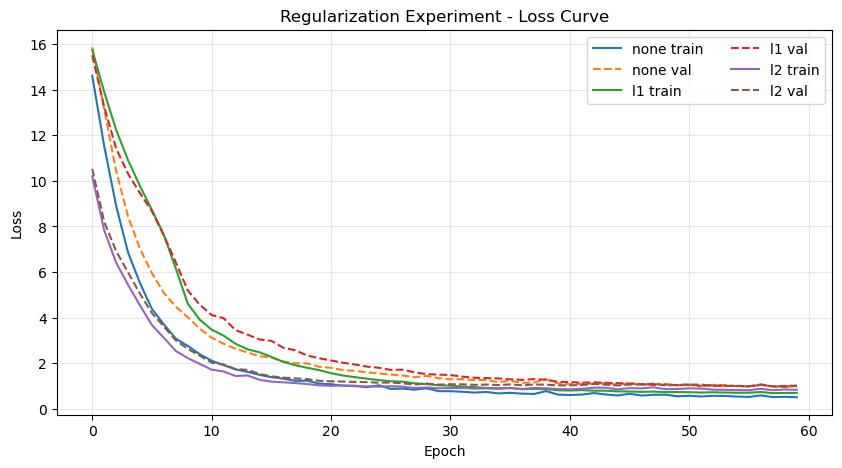

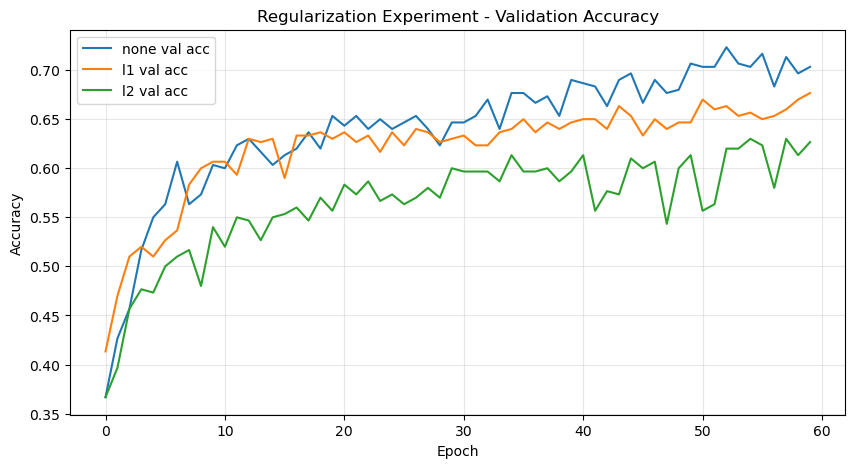

In [10]:
plt.figure(figsize=(10, 5))
for name, hist in regularization_results.items():
    plt.plot(hist['train_loss'], label=f'{name} train')
    plt.plot(hist['val_loss'], linestyle='--', label=f'{name} val')
plt.title('Regularization Experiment - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
for name, hist in regularization_results.items():
    plt.plot(hist['val_acc'], label=f'{name} val acc')
plt.title('Regularization Experiment - Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Perbandingan hasil akhir prediksi (regularisasi)

Menampilkan:
- akurasi akhir di validation set
- distribusi label prediksi akhir
- contoh prediksi untuk sampel yang sama

In [ ]:
y_val_true_idx = np.argmax(y_val, axis=1)
sample_n = 15
sample_idx = np.arange(sample_n)

print('=== Regularization: Prediksi Final ===')
print('True labels :', y_val_true_idx[sample_idx])

for name, reg_type, lam in regularization_variants:
    model = regularization_models[name]
    y_val_prob = model.forward(X_val)
    y_val_pred_idx = np.argmax(y_val_prob, axis=1)

    final_acc = np.mean(y_val_pred_idx == y_val_true_idx)
    pred_counts = np.bincount(y_val_pred_idx, minlength=num_classes)

    print(f'\n[{name}] final val acc = {final_acc:.4f}')
    print('pred class distribution:', pred_counts)
    print('pred labels :', y_val_pred_idx[sample_idx])


=== Regularization: Final Prediction Comparison ===
True labels (first 15): [1 0 0 1 2 1 2 2 1 2 0 2 0 0 1]

[none] final val acc = 0.7033
pred class distribution: [ 82 107 111]
pred labels (first 15): [2 0 0 1 2 1 2 2 1 0 2 2 1 0 1]

[l1] final val acc = 0.6767
pred class distribution: [ 71 111 118]
pred labels (first 15): [1 0 2 1 2 1 2 2 1 1 2 0 1 1 1]

[l2] final val acc = 0.6267
pred class distribution: [ 64 110 126]
pred labels (first 15): [2 2 1 1 2 1 2 2 2 0 2 2 0 1 2]


### Distribusi bobot & gradien (regularisasi)


== Regularization: none ==


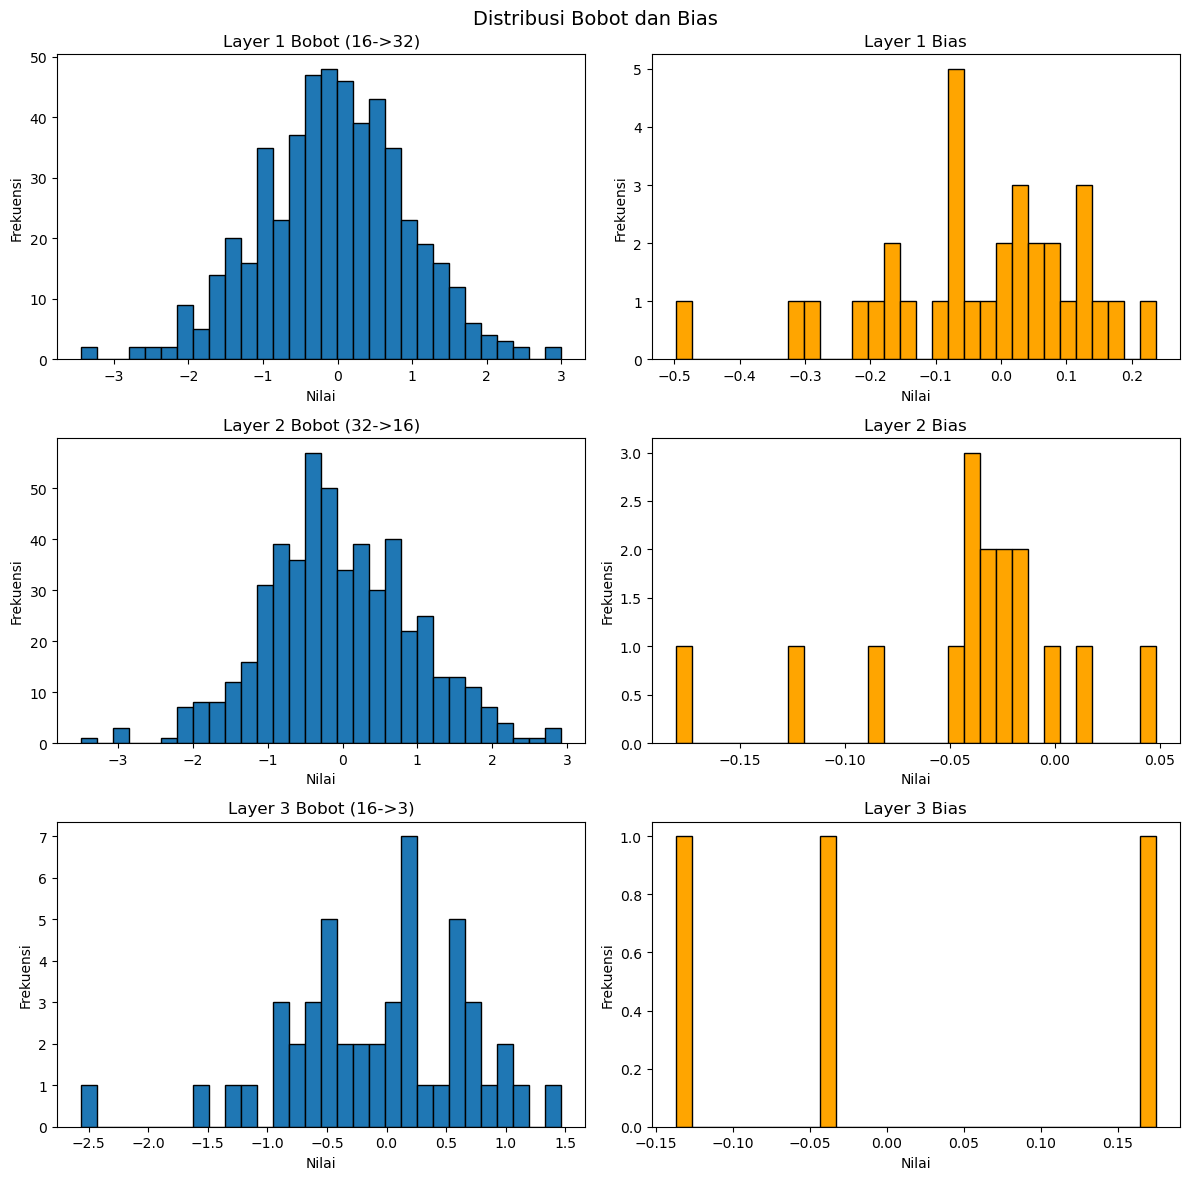

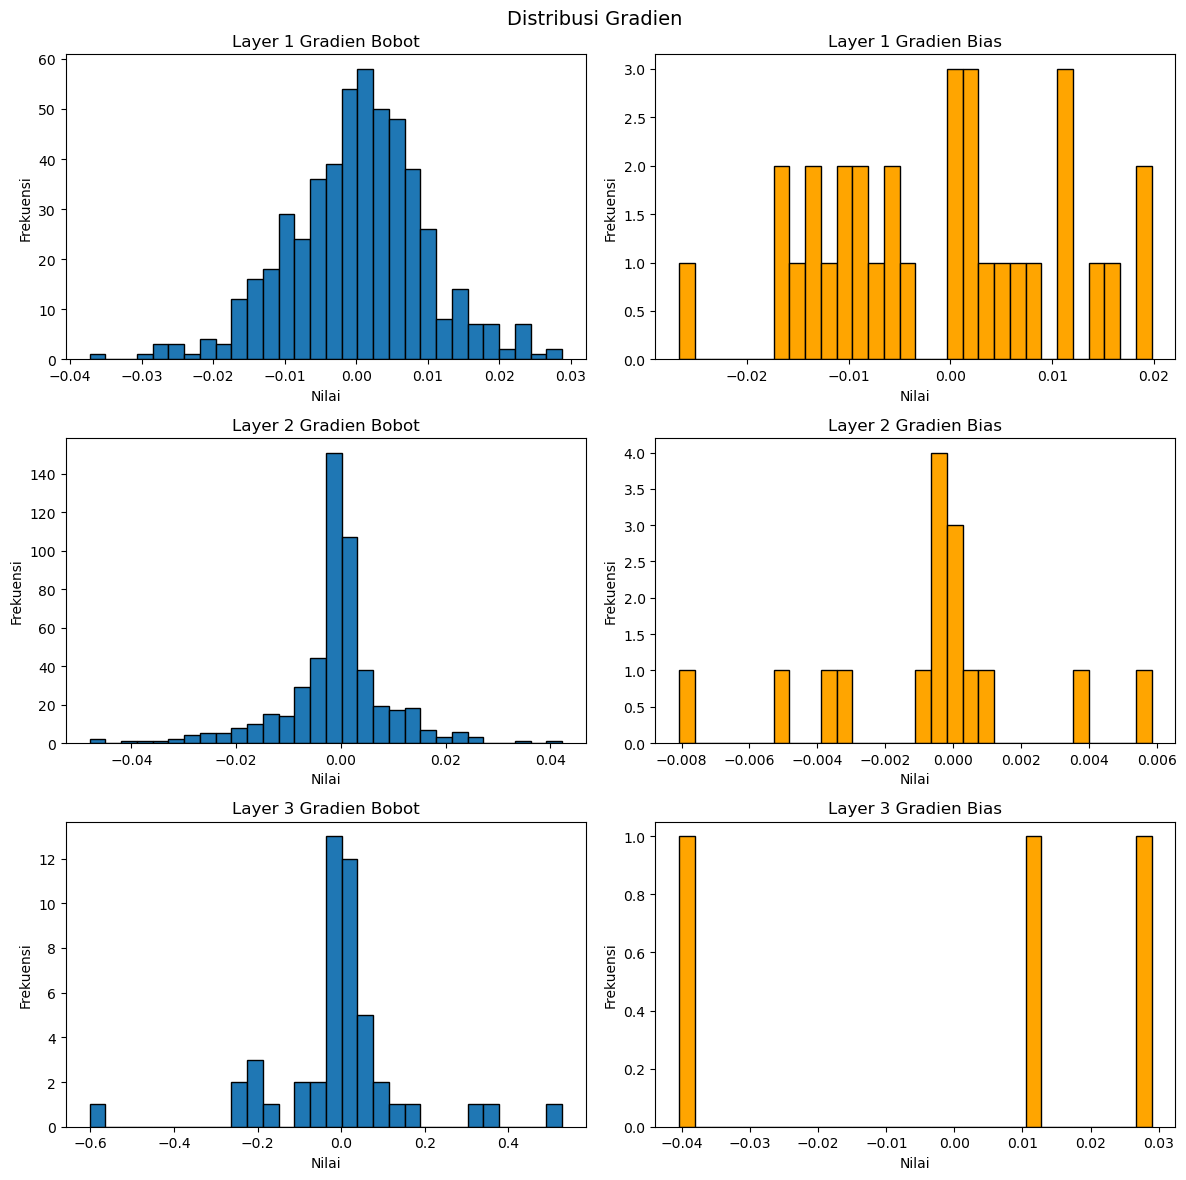

== Regularization: l1 ==


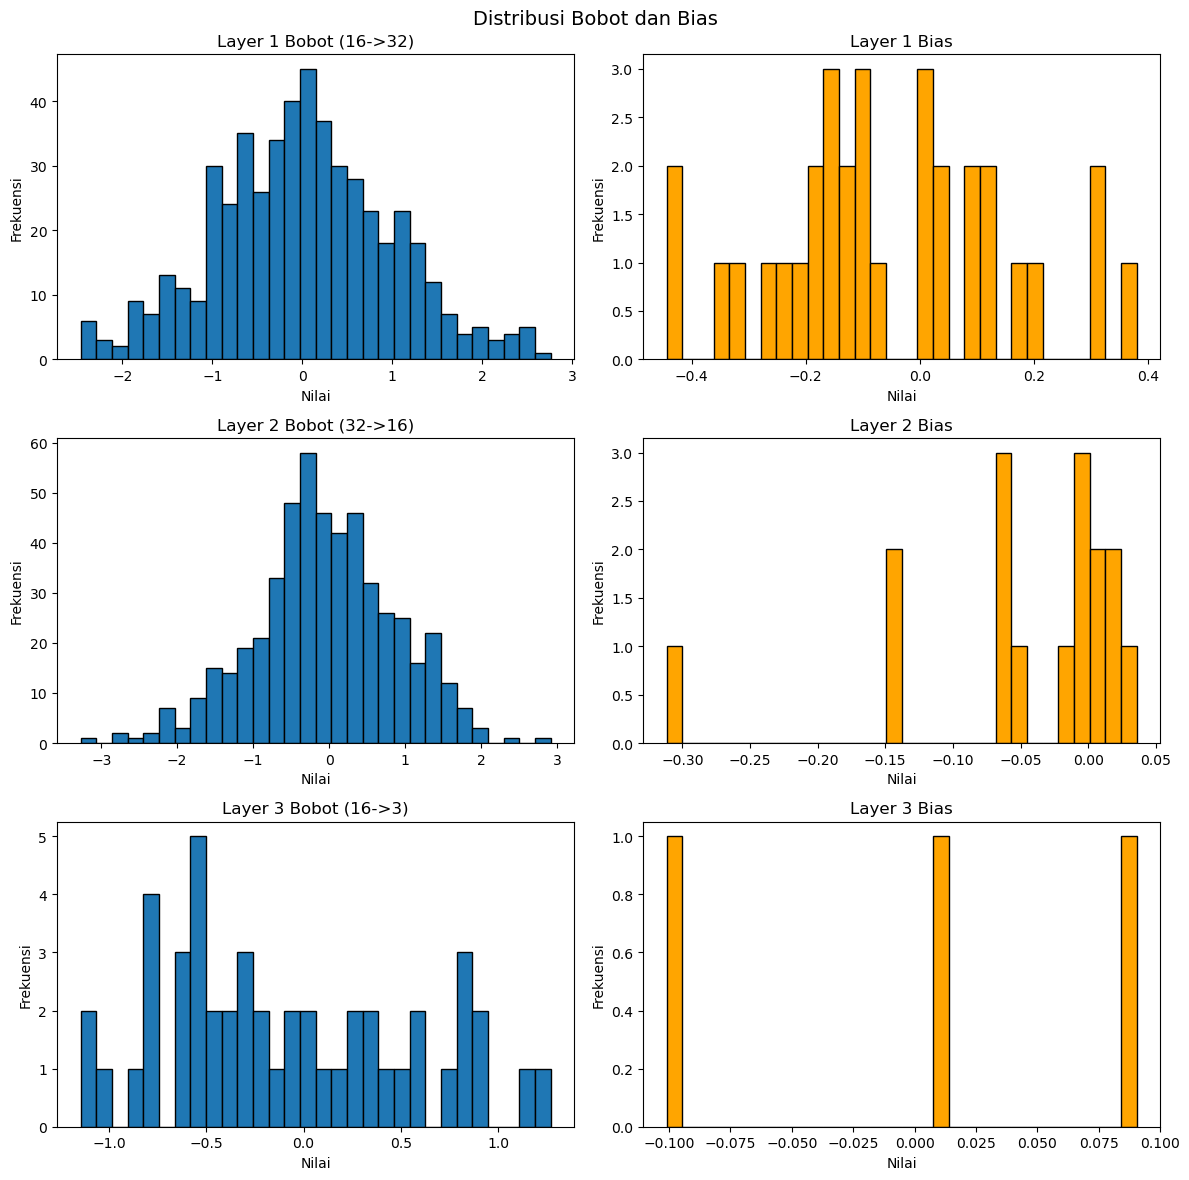

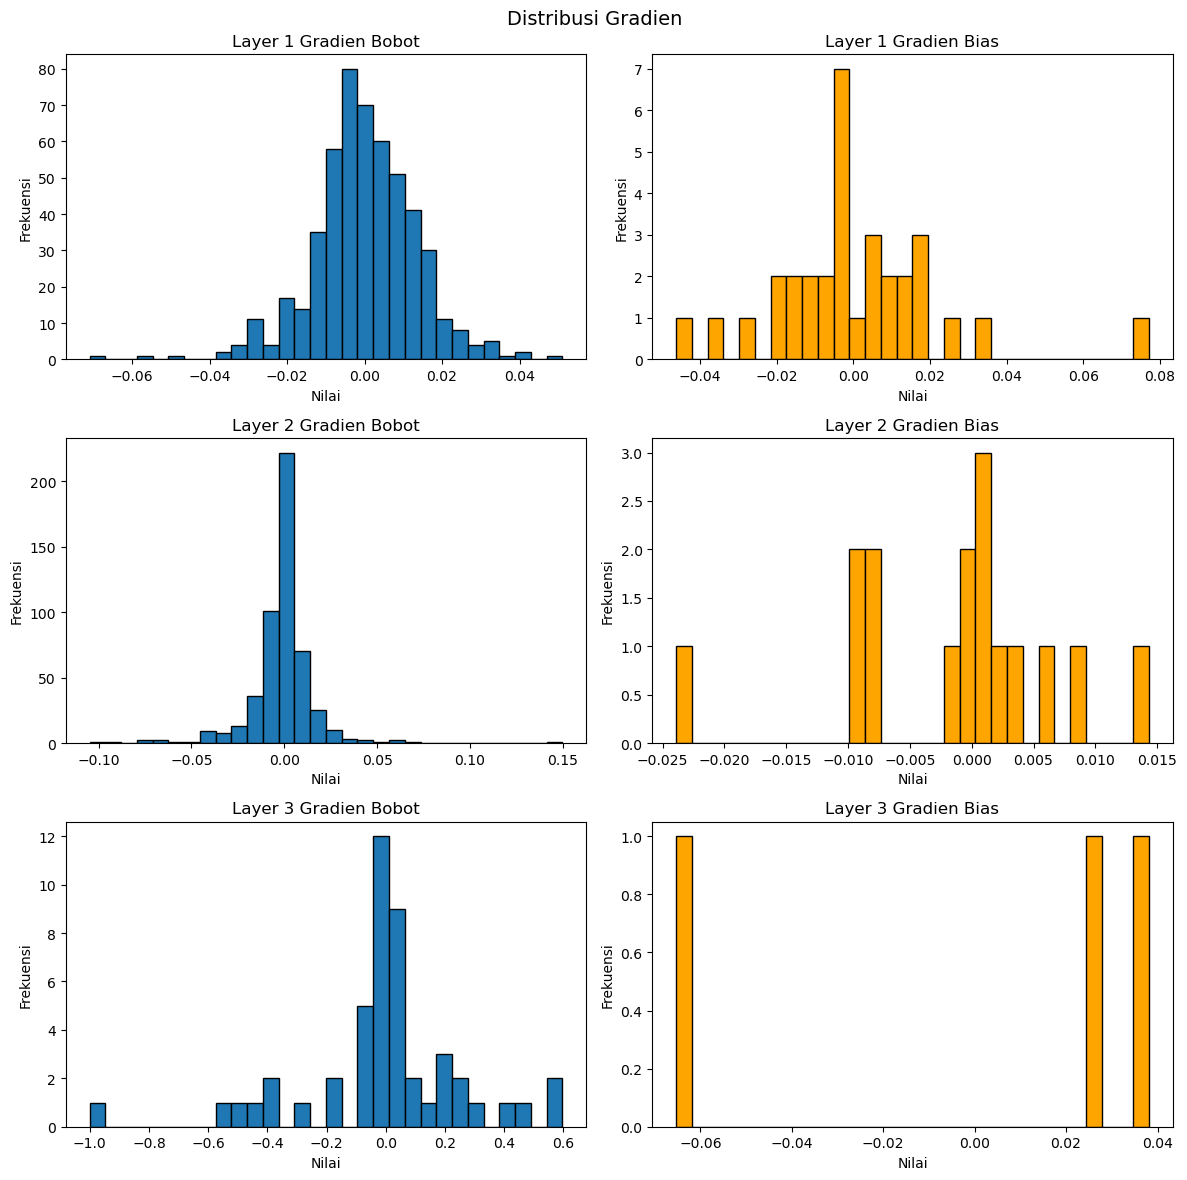

== Regularization: l2 ==


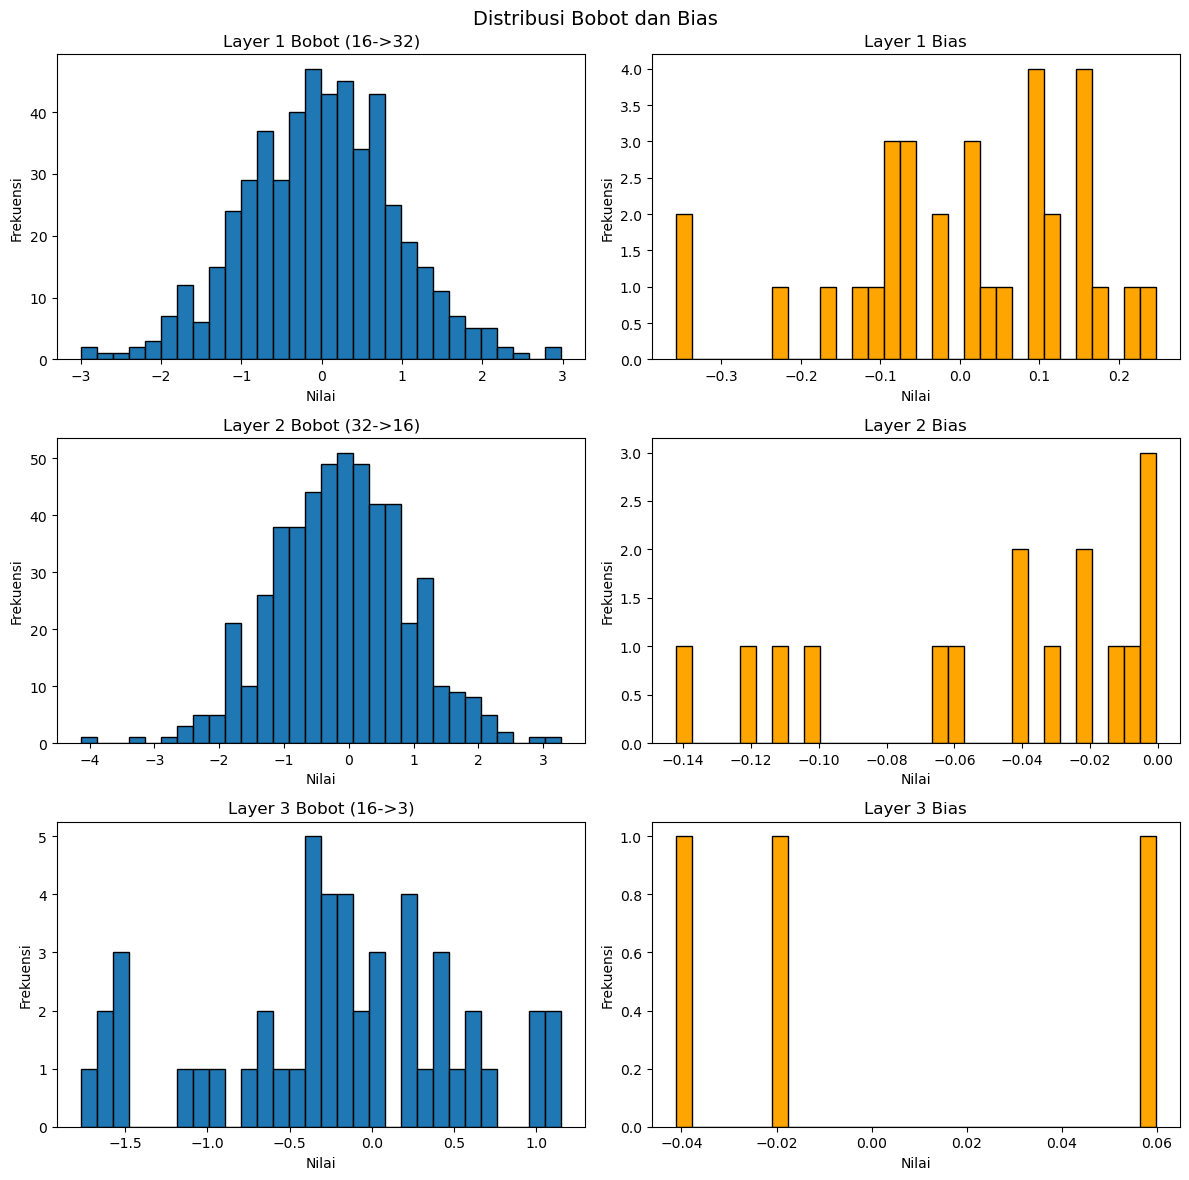

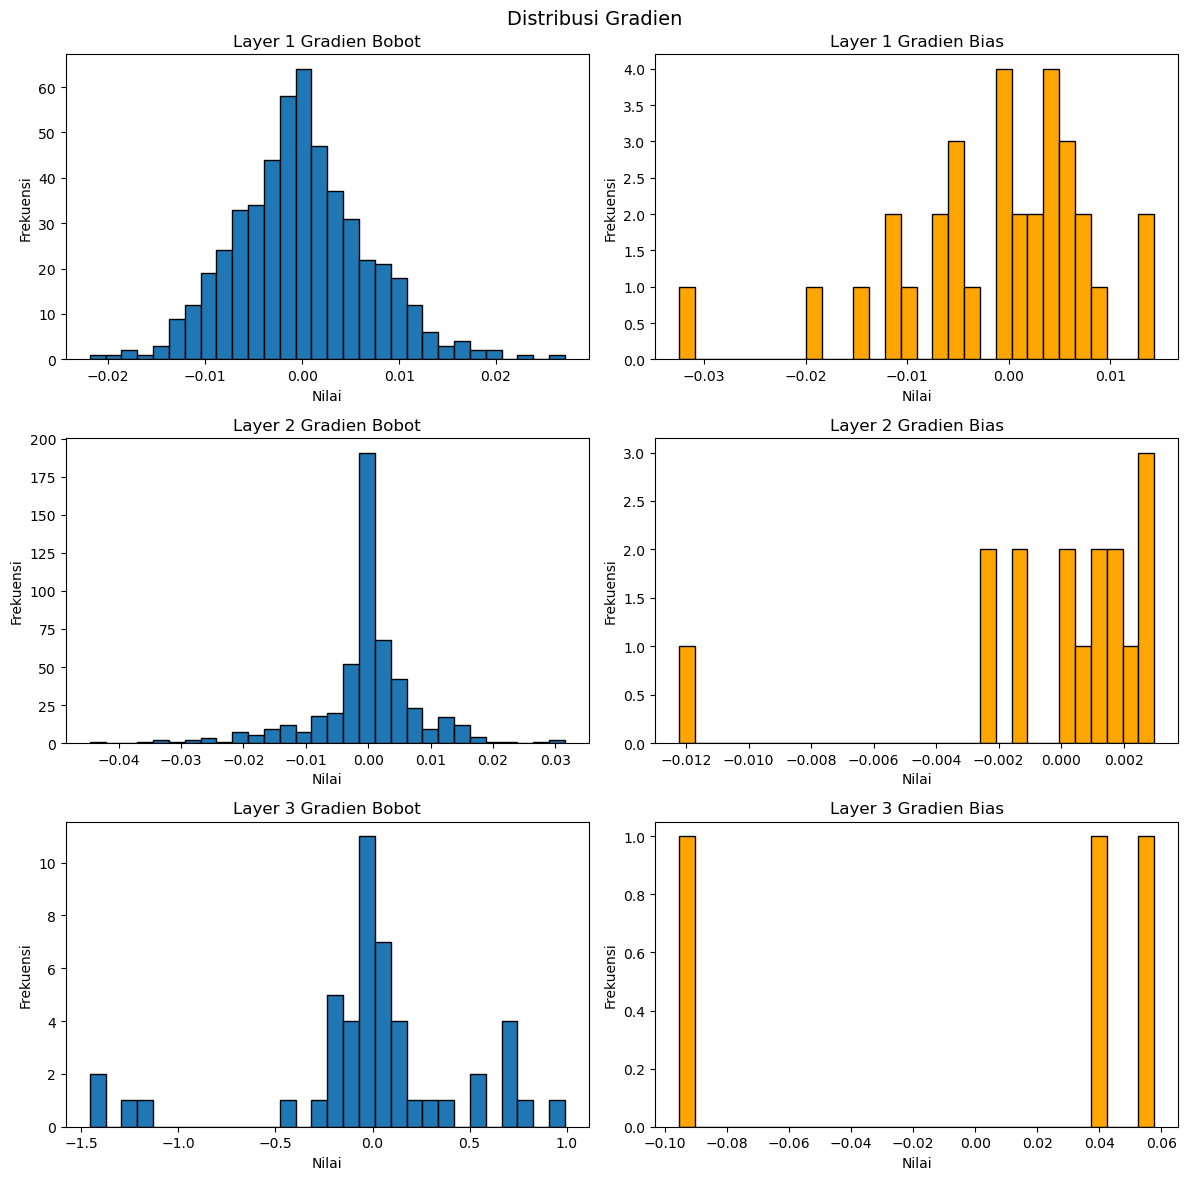

In [12]:
for name, reg_type, lam in regularization_variants:
    model = regularization_models[name]
    _ = model.forward(X_train[:128])
    _ = model.backward(y_train[:128], loss_type=loss_type, reg_type=reg_type, lambda_=lam)

    print(f'== Regularization: {name} ==')
    model.plot_weight_distribution()
    model.plot_gradient_distribution()


## 6) Ringkasan Hasil


In [13]:
print('=== Activation Summary (best val acc) ===')
for act, hist in activation_results.items():
    best_acc = np.max(hist['val_acc'])
    final_acc = hist['val_acc'][-1]
    print(f'{act:8s} | best={best_acc:.4f} | final={final_acc:.4f}')

print('\n=== Regularization Summary (best val acc) ===')
for name, hist in regularization_results.items():
    best_acc = np.max(hist['val_acc'])
    final_acc = hist['val_acc'][-1]
    print(f'{name:8s} | best={best_acc:.4f} | final={final_acc:.4f}')


=== Activation Summary (best val acc) ===
linear   | best=0.7233 | final=0.7067
relu     | best=0.6667 | final=0.6333
sigmoid  | best=0.6900 | final=0.6633
tanh     | best=0.6200 | final=0.6167

=== Regularization Summary (best val acc) ===
none     | best=0.7233 | final=0.7033
l1       | best=0.6767 | final=0.6767
l2       | best=0.6300 | final=0.6267


## 7) Analisis Singkat

- Aktivasi biasanya memengaruhi kecepatan konvergensi dan stabilitas gradien.
- `relu` sering lebih cepat konvergen dibanding `sigmoid` / `tanh` pada setup sederhana.
- `l2` cenderung membuat bobot lebih kecil (lebih smooth), terlihat dari distribusi bobot yang lebih terpusat dekat nol.
- `l1` mendorong sparsity (lebih banyak bobot mendekati nol).
- Pilihan terbaik tetap dilihat dari metrik validasi + stabilitas training curve.
